# Week 6 - Day 2: Activation Functions, Forward Propagation & Loss

I am continuing from the **Heart Disease Classification** project used on Day 1.

**Task:** binary classification of `HeartDisease` (`0` = no heart disease, `1` = heart disease).

Day 1 established the classical ML baseline and the future neural-network input size. Day 2 is about the forward side of a neural network: how activations change the representation, how values move through the layers, and how the final prediction is compared with the true target using a loss function.

For the small forward-pass example, I use only two synthetic inputs so every calculation can be checked by hand. The actual project has more processed features, but the same matrix operations apply.

## 1. Why Activation Functions Matter

A neuron first computes a weighted sum and adds a bias:

$$
z = xW + b
$$

If several layers only repeat affine transformations, the whole stack can still collapse into another affine transformation. For two layers:

$$
h_1 = XW_1 + b_1
$$

$$
h_2 = h_1W_2 + b_2
$$

Substituting the first equation into the second gives:

$$
h_2 = X(W_1W_2) + (b_1W_2 + b_2)
$$

So depth alone is not enough. The activation function is what introduces nonlinearity:

$$
a = f(z)
$$

That nonlinearity is what allows the network to represent relationships that cannot be modeled by one linear decision boundary.

## 2. Imports and Activation Functions

NumPy is enough for the calculations, and Matplotlib is used for the required activation plots.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

np.set_printoptions(precision=4, suppress=True)


def relu(x):
    return np.maximum(0.0, x)


def sigmoid(x):
    return 1.0 / (1.0 + np.exp(-x))


def tanh(x):
    return np.tanh(x)


def softmax(x):
    x = np.asarray(x, dtype=float)
    shifted = x - np.max(x)
    exp_values = np.exp(shifted)
    return exp_values / exp_values.sum()


## 3. ReLU, Sigmoid, and Tanh

The required Day 2 plots use the same input range so their behavior can be compared directly.

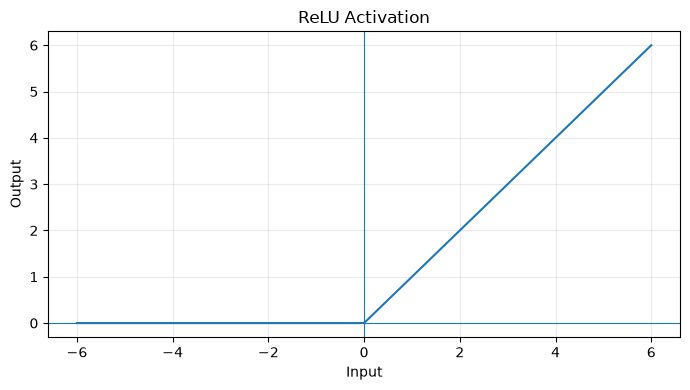

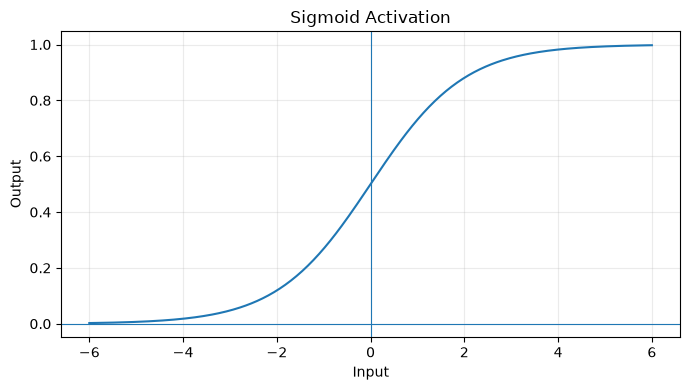

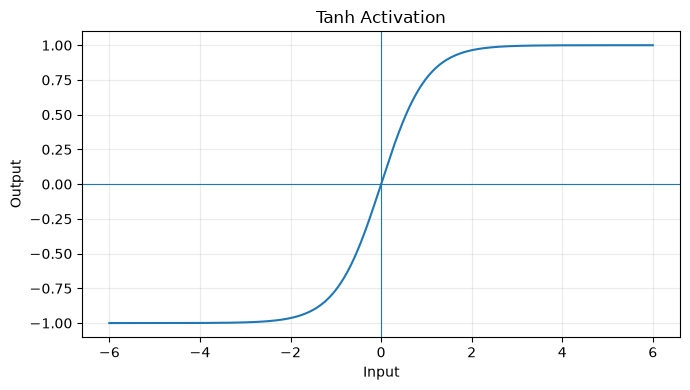

In [2]:
x = np.linspace(-6, 6, 400)

plt.figure(figsize=(7, 4))
plt.plot(x, relu(x))
plt.axhline(0, linewidth=0.8)
plt.axvline(0, linewidth=0.8)
plt.title("ReLU Activation")
plt.xlabel("Input")
plt.ylabel("Output")
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

plt.figure(figsize=(7, 4))
plt.plot(x, sigmoid(x))
plt.axhline(0, linewidth=0.8)
plt.axvline(0, linewidth=0.8)
plt.title("Sigmoid Activation")
plt.xlabel("Input")
plt.ylabel("Output")
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()

plt.figure(figsize=(7, 4))
plt.plot(x, tanh(x))
plt.axhline(0, linewidth=0.8)
plt.axvline(0, linewidth=0.8)
plt.title("Tanh Activation")
plt.xlabel("Input")
plt.ylabel("Output")
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()


### Interpreting the activations

| Activation | Output range | Typical role |
|---|---|---|
| ReLU | $[0, \infty)$ | Common default for hidden dense layers |
| Sigmoid | $(0, 1)$ | Binary-classification output |
| Tanh | $(-1, 1)$ | Zero-centered hidden activation in some architectures |
| Softmax | each value in $(0,1)$, total = 1 | Single-label multi-class output |

### ReLU

$$
ReLU(x) = \max(0, x)
$$

ReLU is simple and nonlinear. Positive values pass through unchanged, while negative values become zero. On the positive side its derivative is 1, so it does not saturate there like sigmoid or tanh.

Its main limitation is the negative side. If the pre-activation of the same neuron stays negative for almost all samples, both the ReLU output and its local derivative stay at zero. That neuron can stop receiving a useful learning signal during training. This is the **dying ReLU** problem.

A common variant is **Leaky ReLU**, which keeps a small slope for negative inputs instead of making the whole negative side exactly zero.

### Sigmoid

$$
\sigma(x) = \frac{1}{1+e^{-x}}
$$

Sigmoid maps a real-valued input to a value between 0 and 1. In a binary output layer, a result such as `0.82` is a probability-like score for class `1`; sigmoid itself does **not** round the value to a class. A decision threshold is applied separately.

### Tanh

Tanh maps values to $(-1,1)$ and is zero-centered. It can be useful in hidden representations, but it also saturates at large positive and negative inputs, where its derivative becomes small.

For the dense network considered in this week, ReLU is the practical default for hidden layers.

## 4. Softmax for Multi-Class Classification

Softmax is normally applied to a vector of output scores, called **logits**:

$$
p_i = \frac{e^{z_i}}{\sum_j e^{z_j}}
$$

It converts the logits into a probability distribution whose values sum to 1. This is useful when exactly one class should be selected from several classes.

In [3]:
logits = np.array([2.0, 1.0, 0.1])
probabilities = softmax(logits)

print("Logits:", logits)
print("Softmax probabilities:", probabilities)
print("Probability sum:", probabilities.sum())
print("Predicted class index:", int(np.argmax(probabilities)))

assert np.isclose(probabilities.sum(), 1.0)


Logits: [2.  1.  0.1]
Softmax probabilities: [0.659  0.2424 0.0986]
Probability sum: 1.0
Predicted class index: 0


If the three outputs represented `Class 0`, `Class 1`, and `Class 2`, the largest softmax probability would determine the predicted class.

This is different from **multi-label** classification, where several labels can be true at the same time. In that case, independent sigmoid outputs are usually more appropriate than one softmax distribution.

## 5. Output Activation and Loss for My Project

The Heart Disease project has one binary target:

- `0` = no heart disease
- `1` = heart disease

The correct output design is therefore:

```text
1 output neuron
        ↓
sigmoid
        ↓
score for class 1
```

In Keras notation, the final layer will later be:

```python
Dense(1, activation="sigmoid")
```

The matching loss is **binary cross-entropy**:

$$
L = -\left[y\log(\hat{y}) + (1-y)\log(1-\hat{y})\right]
$$

This pairing is appropriate because sigmoid produces one score in $(0,1)$ for the positive class, while binary cross-entropy measures how well that score agrees with the true binary label.

A threshold such as `0.5` may later be used to convert the score to class `0` or `1`, but the threshold is not part of the sigmoid function or the loss calculation.

## 6. Loss Functions by Task

A forward pass gives a prediction $\hat{y}$. During training, the loss function compares that prediction with the known target $y$.

The loss is used for optimization because it gives a continuous measure of prediction quality. A metric such as accuracy is useful for evaluation, but it does not tell the optimizer how confidence changed within the same correct or incorrect class.

### Mean Squared Error - Regression

$$
MSE = \frac{1}{N}\sum_{i=1}^{N}(y_i-\hat{y}_i)^2
$$

Squaring prevents positive and negative residuals from cancelling and gives large errors a stronger penalty. That also makes MSE sensitive to large outliers.

Typical pairing:

```text
Regression → linear output → MSE
```

### Binary Cross-Entropy - Binary Classification

$$
BCE = -\left[y\log(\hat{y}) + (1-y)\log(1-\hat{y})\right]
$$

Because $y$ is either 0 or 1, one side of the equation disappears for each sample. A confident wrong prediction receives a much larger loss than a confident correct prediction.

Typical pairing:

```text
Binary classification → sigmoid → binary cross-entropy
```

### Categorical Cross-Entropy - Multi-Class Classification

$$
CCE = -\sum_{c=1}^{C}y_c\log(\hat{y}_c)
$$

With a one-hot target, only the term for the correct class remains in the final loss value.

Typical pairing:

```text
Single-label multi-class classification → softmax → categorical cross-entropy
```

If the class labels are stored as integer indices instead of one-hot vectors, frameworks commonly use **sparse categorical cross-entropy**.

In [4]:
def mse(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    return np.mean((y_true - y_pred) ** 2)


def binary_cross_entropy(y_true, y_pred, eps=1e-12):
    p = np.clip(float(y_pred), eps, 1.0 - eps)
    y = float(y_true)
    return -(y * np.log(p) + (1.0 - y) * np.log(1.0 - p))


def categorical_cross_entropy(y_true, y_pred, eps=1e-12):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.clip(np.asarray(y_pred, dtype=float), eps, 1.0)
    return -np.sum(y_true * np.log(y_pred))


print("MSE example:", mse([10, 20, 30], [9, 18, 33]))

for prediction in [0.90, 0.60, 0.10]:
    loss = binary_cross_entropy(1, prediction)
    print(f"BCE when y=1 and prediction={prediction:.2f}: {loss:.4f}")

true_class = np.array([1.0, 0.0, 0.0])
predicted_probs = np.array([0.70, 0.20, 0.10])
print(
    "CCE example:",
    round(categorical_cross_entropy(true_class, predicted_probs), 4),
)


MSE example: 4.666666666666667
BCE when y=1 and prediction=0.90: 0.1054
BCE when y=1 and prediction=0.60: 0.5108
BCE when y=1 and prediction=0.10: 2.3026
CCE example: 0.3567


The binary cross-entropy examples show why the loss contains more information than accuracy alone. With the true label fixed at `1`, predictions `0.90`, `0.60`, and `0.10` should not receive the same penalty. The loss changes continuously with the confidence of the prediction.

## 7. Forward Propagation Through a Small Two-Layer Network

I use one hidden layer and one output layer, so there are **two trainable layers**.

The sample input is:

$$
x = [2,-1]
$$

The hidden layer has two neurons:

$$
W_1 =
\begin{bmatrix}
1 & 0.5 \\
-1 & 2
\end{bmatrix}
\qquad
b_1 = [0,1]
$$

Using the row-vector convention:

$$
Z_1 = xW_1 + b_1
$$

Each **column** of $W_1$ contains the weights entering one hidden neuron.

For hidden neuron 1:

$$
z_{1,1} = (2)(1) + (-1)(-1) + 0 = 3
$$

For hidden neuron 2:

$$
z_{1,2} = (2)(0.5) + (-1)(2) + 1 = 0
$$

Therefore:

$$
Z_1 = [3,0]
$$

$Z_1$ is the **pre-activation** value. After ReLU:

$$
A_1 = ReLU(Z_1) = [3,0]
$$

$A_1$ is the activated output passed to the next layer.

The output layer uses:

$$
W_2 =
\begin{bmatrix}
0.5 \\
-1
\end{bmatrix}
\qquad
b_2 = -0.5
$$

The output pre-activation is:

$$
Z_2 = A_1W_2 + b_2
$$

$$
Z_2 = (3)(0.5) + (0)(-1) - 0.5 = 1
$$

Because the task is binary classification, the final activation is sigmoid:

$$
\hat{y} = \sigma(1) \approx 0.7311
$$

So the complete forward pass produces a score of about **0.7311** for class `1`.

### NumPy verification

The code below repeats the same calculation using matrix multiplication. I print the shapes because they also show why the weight matrices are arranged this way.

In [5]:
x_sample = np.array([2.0, -1.0])

W1 = np.array([
    [1.0, 0.5],
    [-1.0, 2.0],
])
b1 = np.array([0.0, 1.0])

W2 = np.array([
    [0.5],
    [-1.0],
])
b2 = np.array([-0.5])

Z1 = x_sample @ W1 + b1
A1 = relu(Z1)
Z2 = A1 @ W2 + b2
y_hat = sigmoid(Z2)

print("x shape: ", x_sample.shape)
print("W1 shape:", W1.shape)
print("Z1:", Z1, "shape:", Z1.shape)
print("A1:", A1, "shape:", A1.shape)
print("W2 shape:", W2.shape)
print("Z2:", Z2, "shape:", Z2.shape)
print("Prediction:", y_hat)

assert np.allclose(Z1, np.array([3.0, 0.0]))
assert np.allclose(A1, np.array([3.0, 0.0]))
assert np.allclose(Z2, np.array([1.0]))
assert np.allclose(y_hat, np.array([0.73105858]), atol=1e-8)


x shape:  (2,)
W1 shape: (2, 2)
Z1: [3. 0.] shape: (2,)
A1: [3. 0.] shape: (2,)
W2 shape: (2, 1)
Z2: [1.] shape: (1,)
Prediction: [0.7311]


### Forward-pass interpretation

The calculation can be summarized as:

$$
x
\rightarrow
Z_1=xW_1+b_1
\rightarrow
A_1=ReLU(Z_1)
\rightarrow
Z_2=A_1W_2+b_2
\rightarrow
\hat{y}=\sigma(Z_2)
$$

For this sample:

$$
[2,-1]
\rightarrow
[3,0]
\rightarrow
[3,0]
\rightarrow
[1]
\rightarrow
[0.7311]
$$

No learning happens in this forward pass. The weights and biases were fixed manually. Forward propagation only computes the prediction using the current parameter values.

## 8. Connecting the Prediction to the Loss

Suppose the true target for the sample is:

$$
y = 1
$$

The forward pass produced:

$$
\hat{y} \approx 0.7311
$$

The next step in the training loop is to compare the prediction with the true label using binary cross-entropy.

Backpropagation and weight updates come **after** this point, so they are intentionally not implemented in the Day 2 notebook.

In [6]:
y_true = 1
sample_loss = binary_cross_entropy(y_true, y_hat[0])

print(f"Prediction: {y_hat[0]:.4f}")
print(f"True label: {y_true}")
print(f"Binary cross-entropy loss: {sample_loss:.4f}")

assert np.isclose(sample_loss, 0.3132616875, atol=1e-9)


Prediction: 0.7311
True label: 1
Binary cross-entropy loss: 0.3133


## 9. Day 2 Summary

The main decisions and results are now clear:

- nonlinear activations are required so stacked layers do not reduce to one affine transformation,
- ReLU is the practical hidden-layer default for the dense network used this week,
- sigmoid is the correct output activation for the Heart Disease binary target,
- binary cross-entropy is the matching loss for that output,
- softmax with categorical cross-entropy is the standard pairing for single-label multi-class classification,
- the small two-layer forward pass was checked manually and with NumPy,
- the example produced $\hat{y} \approx 0.7311$ and BCE $\approx 0.3133$ for a true label of `1`,
- backpropagation, gradients, and optimizer updates belong to Day 3.

The forward side of the training loop:

```text
input → weighted sum + bias → activation → next layer → prediction → loss
```